# Logistic Regression

## 0. Package Importing

In [4]:
from utils import *

## 1. Data Loading

In [5]:
data = pd.read_csv('game_prediction.csv')
x = data[['gold_difference(K)']]
y = data[['win_or_lose']]

x = np.r_[x]
y = np.r_[y]
N=len(x)

## 2. Data Plotting

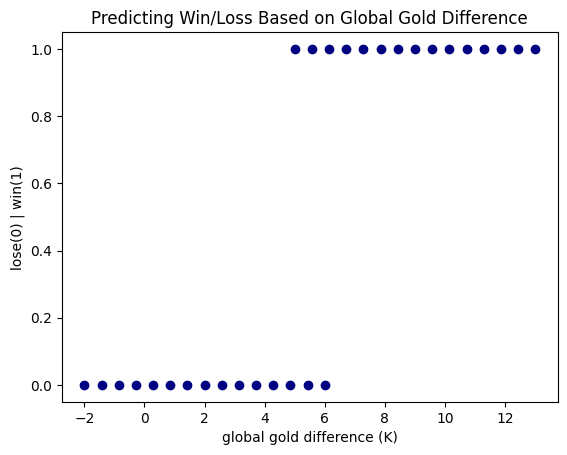

In [6]:
plt.scatter(x,y, c='navy')
plt.xlabel('global gold difference (K)')
plt.ylabel('lose(0) | win(1)')
plt.title('Predicting Win/Loss Based on Global Gold Difference')
plt.show()

## 3. Regression Line Plotting

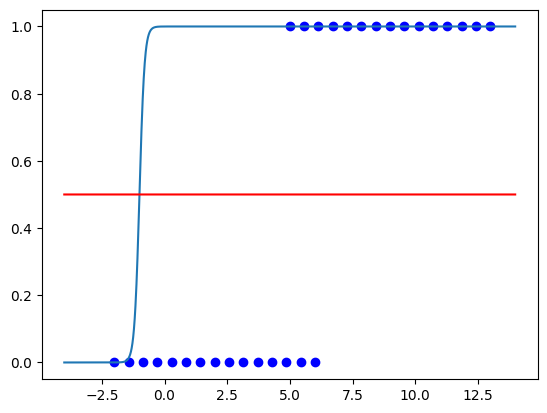

In [7]:
W=10
b=10

x_plot = np.arange(-4,14,0.01)
y_plot = np.exp(W*x_plot + b)/(1+np.exp(W*x_plot + b))
plt.plot(x_plot, y_plot)
plt.plot(x_plot, 0.5*np.ones_like(x_plot), c='red')
plt.scatter(x, y, c='blue')
plt.show()

## 4. Parameter Fitting: Gradient Descent

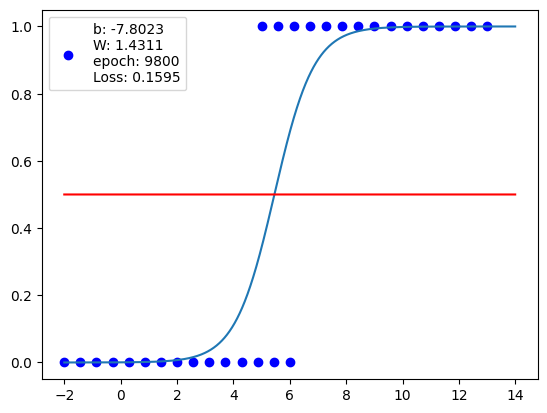

In [8]:
################# initialize hyperparams ######################
learning_rate = 5e-2
epochs = 10000
time_sleep = 0.2
W = 1
b = 1
epoch_interval = 200
#################################################################

loss_list = []
W_list = []
b_list = []
for epoch in range(epochs):
    z = W*x + b

    # sigmoid function
    p = np.exp(z)/(1+np.exp(z))

    # Negative log likelihood
    loss = -np.sum(y*np.log(p)+(1-y)*np.log(1-p))/N

    # compute Gradient
    p_prime = p*(1-p)
    p_prime_W = p_prime*x
    p_prime_b = p_prime*1
    W_grad = -np.sum(y/p*p_prime_W-(1-y)/(1-p)*p_prime_W)/N
    b_grad = -np.sum(y/p*p_prime_b-(1-y)/(1-p)*p_prime_b)/N

    # update
    W = W - learning_rate*W_grad
    b = b - learning_rate*b_grad

    if epoch%epoch_interval == 0 :
        plt.figure()
        x_plot = np.arange(-2,14,0.01)
        y_plot = np.exp(W*x_plot + b)/(1+np.exp(W*x_plot + b))
        plt.plot(x_plot, y_plot)
        plt.plot(x_plot, 0.5*np.ones_like(x_plot), c='red')
        plt.scatter(x, y, c= 'blue', label = f'b: {b:.4f}\nW: {W:.4f}\nepoch: {epoch}\nLoss: {loss:.4f}')
        plt.legend()
        plt.show()
        time.sleep(time_sleep)
        clear_output(wait=True)

        loss_list.append(loss)
        W_list.append(W)
        b_list.append(b)

In [9]:
for l, w, b in zip(loss_list, W_list, b_list):
    print(f"loss:{l:.4f}, W:{w:.4f}, b:{b:.4f}")

loss:1.6286, W:0.9463, b:0.9795
loss:0.3910, W:0.3077, b:-0.9995
loss:0.2981, W:0.4443, b:-1.9404
loss:0.2591, W:0.5387, b:-2.5541
loss:0.2373, W:0.6116, b:-3.0130
loss:0.2233, W:0.6714, b:-3.3822
loss:0.2134, W:0.7223, b:-3.6925
loss:0.2059, W:0.7669, b:-3.9610
loss:0.2001, W:0.8066, b:-4.1984
loss:0.1955, W:0.8425, b:-4.4115
loss:0.1916, W:0.8753, b:-4.6051
loss:0.1883, W:0.9054, b:-4.7826
loss:0.1856, W:0.9334, b:-4.9466
loss:0.1832, W:0.9595, b:-5.0992
loss:0.1811, W:0.9840, b:-5.2419
loss:0.1792, W:1.0071, b:-5.3759
loss:0.1776, W:1.0289, b:-5.5023
loss:0.1761, W:1.0495, b:-5.6219
loss:0.1748, W:1.0692, b:-5.7354
loss:0.1736, W:1.0879, b:-5.8434
loss:0.1725, W:1.1058, b:-5.9465
loss:0.1715, W:1.1229, b:-6.0450
loss:0.1706, W:1.1393, b:-6.1394
loss:0.1697, W:1.1551, b:-6.2299
loss:0.1689, W:1.1703, b:-6.3169
loss:0.1682, W:1.1849, b:-6.4007
loss:0.1675, W:1.1990, b:-6.4814
loss:0.1669, W:1.2126, b:-6.5593
loss:0.1663, W:1.2257, b:-6.6345
loss:0.1658, W:1.2385, b:-6.7072
loss:0.1653